## Section 1 — Import Libraries

In [23]:
# Import libraries for data analysis, visualization, and machine learning

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Section 2 — Load Dataset

In [24]:
# Load the housing dataset

df = pd.read_csv("../data/housing.csv")

# Display the first five rows of the dataset
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Section 3 — Dataset Overview

In [25]:
# Display dataset structure including column names, data types, and missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [26]:
# Generate statistical summary of numerical features

df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [27]:
# Generate statistical summary of numerical features

df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Section 4 — Missing Value Check

In [28]:
# Check missing values in each column

df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## Section 5 — Data Cleaning

In [29]:
# Fill missing values in the total_bedrooms column using the median

df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)

## Section 6 — Exploratory Data Analysis

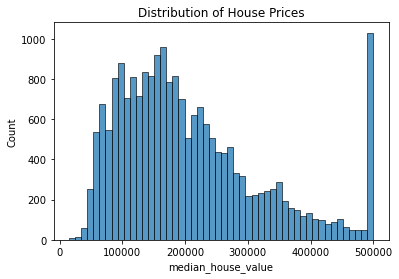

In [30]:
# Visualize distribution of house prices

sns.histplot(df["median_house_value"], bins=50)

plt.title("Distribution of House Prices")

plt.show()

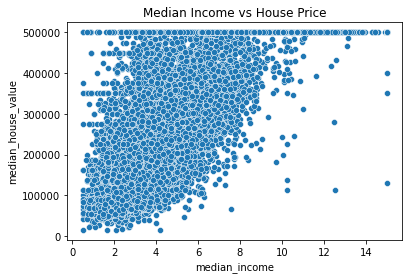

In [31]:
# Relationship between median income and house prices

sns.scatterplot(
    x="median_income",
    y="median_house_value",
    data=df
)

plt.title("Median Income vs House Price")

plt.show()

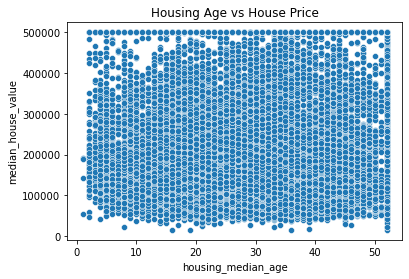

In [32]:
# Relationship between housing age and house price

sns.scatterplot(
    x="housing_median_age",
    y="median_house_value",
    data=df
)

plt.title("Housing Age vs House Price")

plt.show()

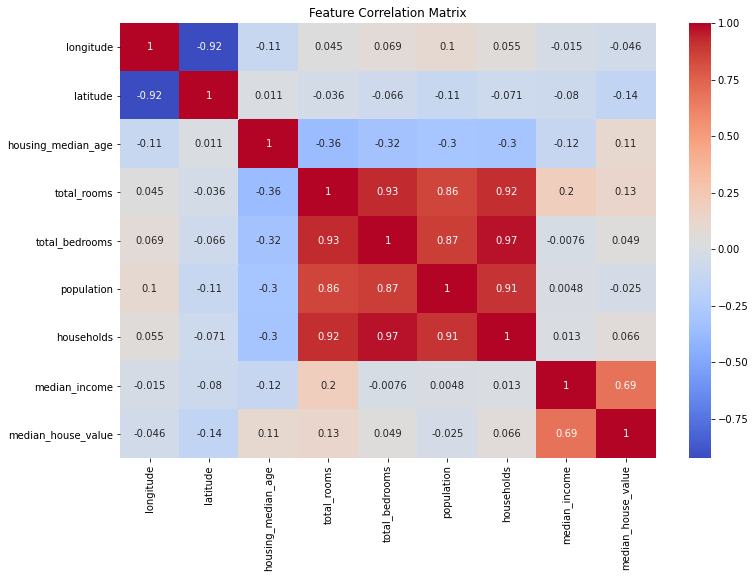

In [33]:
# Correlation Heatmap
# Visualize correlation between numerical features

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.show()

## Section 7 - Feature Engineering

In [34]:
# Feature Engineering

# Average rooms per household
df["rooms_per_household"] = df["total_rooms"] / df["households"]

# Average bedrooms per room
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

# Population per household
df["population_per_household"] = df["population"] / df["households"]

## Section 8 — Feature Selection

In [35]:
features = [
    "median_income",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "latitude",
    "longitude",
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household"
]

X = df[features]
y = df["median_house_value"]

## Section 9 — Train Test Split

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Section 10 — Model Training

In [37]:
# Train a Linear Regression model

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [38]:
# Train Random Forest model

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [39]:
# Train Gradient Boosting Regressor

from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor()

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

## Section 11 — Model Comparison

In [40]:
# Compare model performance using Mean Absolute Error

from sklearn.metrics import mean_absolute_error

lr_mae = mean_absolute_error(y_test, lr_pred)

rf_mae = mean_absolute_error(y_test, rf_pred)

gb_mae = mean_absolute_error(y_test, gb_pred)

print("Linear Regression MAE:", lr_mae)

print("Random Forest MAE:", rf_mae)

print("Gradient Boosting:", gb_mae)

Linear Regression MAE: 51930.36012025871
Random Forest MAE: 33209.847616193656
Gradient Boosting: 37212.99522735974


## Section 12 — Model Evaluation

In [41]:
from sklearn.metrics import r2_score

print("Linear Regression R2:", r2_score(y_test, lr_pred))

print("Random Forest R2:", r2_score(y_test, rf_pred))

print("Gradient Boosting R2:", r2_score(y_test, gb_pred))

Linear Regression R2: 0.5792626798776633
Random Forest R2: 0.8024915038196949
Gradient Boosting R2: 0.7743960471179783


## Section - 13 The Final Model Score 

In [42]:
# Evaluate final model performance

from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, rf_pred)
mae = mean_absolute_error(y_test, rf_pred)

print("Final Random Forest R2 Score:", r2)
print("Mean Absolute Error:", mae)

Final Random Forest R2 Score: 0.8024915038196949
Mean Absolute Error: 33209.847616193656


## Section 14 — Feature Importance

"This visualization shows which features have the greatest impact on predicting house prices."

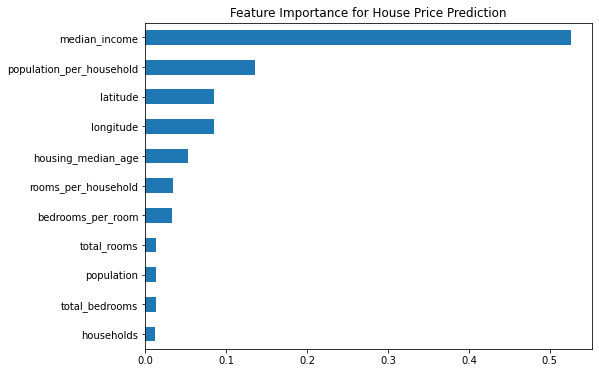

In [43]:
# Plot feature importance from the trained Random Forest model

importance = rf_model.feature_importances_

feature_names = X.columns

feature_importance = pd.Series(importance, index=feature_names)

feature_importance.sort_values().plot(kind="barh", figsize=(8,6))

plt.title("Feature Importance for House Price Prediction")

plt.show()

## Section 15 — Save Model

In [1]:
# Save trained model for deployment

import pickle

pickle.dump(rf_model, open("../model/house_model.pkl", "wb"))

NameError: name 'rf_model' is not defined